# <img src="https://img.icons8.com/bubbles/50/000000/mind-map.png" style="height:50px;display:inline"> ECE 046211 - Technion - Deep Learning
---

## HW2 - Multilayer NNs and Convolutional NNs
---

### <img src="https://img.icons8.com/clouds/96/000000/keyboard.png" style="height:50px;display:inline"> Keyboard Shortcuts
---
* Run current cell: **Ctrl + Enter**
* Run current cell and move to the next: **Shift + Enter**
* Show lines in a code cell: **Esc + L**
* View function documentation: **Shift + Tab** inside the parenthesis or `help(name_of_module)`
* New cell below: **Esc + B**
* Delete cell: **Esc + D, D** (two D's)

### <img src="https://img.icons8.com/bubbles/50/000000/information.png" style="height:50px;display:inline"> Students Information
---
* Fill in

|Name     |Campus Email| ID  |
|---------|--------------------------------|----------|
|Student 1| student_1@campus.technion.ac.il| 123456789|
|Student 2| student_2@campus.technion.ac.il| 987654321|


### <img src="https://img.icons8.com/bubbles/50/000000/upload-to-cloud.png" style="height:50px;display:inline"> Submission Guidelines
---
* Maximal garde: 100.
* Submission only in **pairs**.
    * Please make sure you have registered your group in Moodle (there is a group creation component on the Moodle where you need to create your group and assign members).
* **No handwritten submissions.** You can choose whether to answer in a Markdown cell in this notebook or attach a PDF with your answers.
* <a style='color:red'> SAVE THE NOTEBOOKS WITH THE OUTPUT, CODE CELLS THAT WERE NOT RUN WILL NOT GET ANY POINTS! </a>
* What you have to submit:
    * If you have answered the questions in the notebook, you should submit this file only, with the name: `ece046211_hw2_id1_id2.ipynb`.
    * If you answered the questions in a different file you should submit a `.zip` file with the name `ece046211_hw2_id1_id2.zip` with content:
        * `ece046211_hw2_id1_id2.ipynb` - the code tasks.
        * `ece046211_hw2_id1_id2.pdf` - answers to questions.
    * No other file-types (`.py`, `.docx`...) will be accepted.
* Submission on the course website (Moodle).
* **Latex in Colab** - in some cases, Latex equations may no be rendered. To avoid this, make sure to not use *bullets* in your answers ("* some text here with Latex equations" -> "some text here with Latex equations").

### <img src="https://img.icons8.com/dusk/64/000000/online.png" style="height:50px;display:inline"> Working Online and Locally
---
* You can choose your working environment:
    1. `Jupyter Notebook`, **locally** with <a href="https://www.anaconda.com/distribution/">Anaconda</a> or **online** on <a href="https://colab.research.google.com/">Google Colab</a>
        * Colab also supports running code on GPU, so if you don't have one, Colab is the way to go. To enable GPU on Colab, in the menu: `Runtime`$\rightarrow$ `Change Runtime Type` $\rightarrow$`GPU`.
    2. Python IDE such as <a href="https://www.jetbrains.com/pycharm/">PyCharm</a> or <a href="https://code.visualstudio.com/">Visual Studio Code</a>.
        * Both allow editing and running Jupyter Notebooks.

* Please refer to `Setting Up the Working Environment.pdf` on the Moodle or our GitHub (https://github.com/taldatech/ee046211-deep-learning) to help you get everything installed.
* If you need any technical assistance, please go to our Piazza forum (`hw2` folder) and describe your problem (preferably with images).

### <img src="https://img.icons8.com/bubbles/50/000000/checklist.png" style="height:50px;display:inline"> Agenda
---

* [Part 1 - Theory](#-Part-1---Theory)
    * [Q1 - Generalization in A Teacher-Student Setup](#-Question-1--Generalization-in-A-Teacher-Student-Setup)
    * [Q2 - "Typical" Generalization in Multilayer Neural Networks](#-Question-2---"Typical"-Generalization-in-Multilayer-Neural-Networks)
    * [Q3 - Deep Double Descent](#-Question-3---Deep-Double-Descent)
    * [Q4 - Initialization](#-Question-4---Initialization)
    * [Q5 - Equivariance](#-Question-5---Equivariance)
    * [Q6 - VGG Architecture](#-Question-6--VGG-Architecture)
* [Part 2 - Code Assignments](#-Part-2---Code-Assignments)
    * [Task 1 - The Importance of Activation and Initialization](#-Task-1---The-Importance-of-Activation-and-Initialization)
    * [Task 2 - MLP-based Deep Classifer](#-Task-2---MLP-based-Deep-Classifer)
    * [Task 3 - Design a CNN](#-Task-3---Design-a-CNN)
* [Credits](#-Credits)

### <img src="https://img.icons8.com/cute-clipart/64/000000/ball-point-pen.png" style="height:50px;display:inline"> Part 1 - Theory
---
* You can choose whether to answser these straight in the notebook (Markdown + Latex) or use another editor (Word, LyX, Latex, Overleaf...) and submit an additional PDF file, **but no handwritten submissions**.
* You can attach additional figures (drawings, graphs,...) in a separate PDF file, just make sure to refer to them in your answers.

* $\large\LaTeX$ <a href="https://kapeli.com/cheat_sheets/LaTeX_Math_Symbols.docset/Contents/Resources/Documents/index">Cheat-Sheet</a> (to write equations)
    * <a href="http://tug.ctan.org/info/latex-refsheet/LaTeX_RefSheet.pdf">Another Cheat-Sheet</a>

## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 1 - Generalization in Multilayer Neural Networks
---

Recall from lecture 4 the Bayes Risk $\mathcal{\overline{R}}(w)$: $$ \mathcal{\overline{R}}(w) \triangleq \mathbb{E}_{\epsilon \sim \mathcal{N}(0, \sigma_{\epsilon}^2I), w_{true} \sim \mathcal{N}(0,\frac{\sigma_w^2}{d}I) } \left[\mathcal{R}\right], $$ where, $$ \mathcal{R}(w_{\mu}) = ||w_{\mu}-w_{true}||^2 = ||(H_{\mu}^{-1}H-I)w_{true} + H_{\mu}^{-1}X^T\epsilon||^2 $$

Prove:

$$ \overline{\mathcal{R}}(w_{\mu}) = \sum_{i=1}^d \frac{(\sigma_w^2/d) \mu^2 + \sigma_{\epsilon}^2 \lambda_i}{(\lambda_i + \mu)^2} $$

Hints:
* $\mathbb{E} \left[\epsilon^TXH_{\mu}^{-1}H_{\mu}^{-1}X^T\epsilon \right] = \sum_{i,j}^N\mathbb{E}[\epsilon_i \epsilon_j] \left(XH_{\mu}^{-1} \right)_i\left(H_{\mu}^{-1}X^T \right)_j$

* $\mathbb{E}[\epsilon_i \epsilon_j] = \sigma_{\epsilon}^2 \delta_{ij}$

* $\sum_{i=1}^N \left(XH_{\mu}^{-1} \right)_i\left(H_{\mu}^{-1}X^T \right)_i = Tr\left[XH_{\mu}^{-2}X^T \right] $

## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 2 - Learning with a single layer
---

Given a ReLU network with one hidden layer and (k) neurons, without biases:
$$
f(\mathbf{x})=\sum_{i=1}^{k} w_2[i],[\mathbf{W}_1[i,:]\mathbf{x}]
$$

The network is trained using Gradient Flow with a squared loss and (L^2) regularization:
$$
\mathcal{L}=\frac{1}{N}\sum_{n=1}^{N}(y^{(n)}-f(x^{(n)}))^2+\mu\left(\sum_{i=1}^{k} w_2[i]^2+|\mathbf{W}_1[i,:]|^2\right)
$$

with labeled samples $({(\mathbf{x}^{(n)},y^{(n)})}_{n=1}^N)$, where $(N<k)$, and all samples $(\mathbf{x}^{(n)}\in\mathbb{R}^d)$ are distinct.
$(\mathbf{W}_1)$ is initialized randomly and normalized such that $(\forall i:|\mathbf{W}_1[i,:]|=1)$, and the hidden layer outputs $({\mathbf{v}^{(n)}=[\mathbf{W}_1\mathbf{x}^{(n)}]}_{n=1}^N)$ span an (N)-dimensional space.
$(\mathbf{w}_2)$ is initialized to zero.

In this question, assume $(\mathbf{W}_1)$ is frozen, and only the second layer $(\mathbf{w}_2)$ is trained.

1. Prove that without regularization, i.e. $(\mu=0)$, the solution converges to zero training error.

2. For $(\mu=0)$, can $(\mathbf{w}_2)$ leave the subspace spanned by $({\mathbf{v}^{(n)}}_{n=1}^N)$? Explain.

3. Prove that when $(\mu=0)$, the second layer converges to the solution minimizing the squared norm:
   $$
   \min_{\mathbf{w}_2}\ |\mathbf{w}_2|^2 \quad \text{such that}\quad \sum_{i=1}^{k}w_2[i][\mathbf{W}_1[i,:]\mathbf{x}^{(n)}]=y^{(n)}
   $$
   Hint: Write the optimality conditions for this problem using Lagrange multipliers, and show that GD converges to a solution satisfying these conditions.

4. With regularization, i.e. $(\mu>0)$, to what solution do we converge? A proof is not required.

## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 3 - Deep Double Descent
---

For the following plots:
1. Where is the critical point (the point of transition between the "Classical Regime" and "Modern Regime") of the deep double descent?
2. What type of double descent is shown (**look closely at the graph**)? Explain. There can be more than one correct answer.
    

a. <img src='https://raw.githubusercontent.com/taldatech/ee046211-deep-learning/main/assets/double_descent_transformer.PNG' style="height:300px">

b. <img src='https://raw.githubusercontent.com/taldatech/ee046211-deep-learning/main/assets/double_descent_resnet.PNG' style="height:400px">

c. <img src='https://raw.githubusercontent.com/taldatech/ee046211-deep-learning/main/assets/double_descent_intermediate.PNG' style="height:300px">


## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 4 - Initialization
---
Recall that in lecture 5 we were discussing how to calculate the initialization variance, and reached the conclusion that $$ \sigma_l =\frac{1}{\sqrt{\sum_j \mathbb{E} \left[\varphi^2(u_{l-1}[j])\right]}} $$
Show that for ReLU activation ($\varphi(z) = max(0,z)$), the optimal variance satisfies: $$ \sigma_l = \sqrt{\frac{2}{d_{l-1}}}$$

1. Under the assumption that the distribution of $W$ is symmetric ($\to$ the distribution of $u$ is symmetric).
2. Using the central limit theorem for large width.

Answer each section **separately** and assume the sections are independent.

All the notations are the same as in the lecture slides.



## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 5 - Equivariance
---

Recall from lecture 6:
A function $f: \mathbb{R}^d \to \mathbb{R}^d$ is equivariant if $f(\tau \cdot x) = \tau \cdot f(x)$ for all $\tau$.

Let $f_w(x) = \phi (Wx)$ where $\phi$ is a component-wise non-linearity and $W \in \mathbb{R}^{d\times d}$. Prove that $f_w:\mathbb{R}^d \to \mathbb{R}^d$ is equivariant to transformation family $H$ **if and only if**: $$ \forall \tau \in H, W[i, j] = W[\tau(i), \tau(j)] $$

* As in class, $\tau$ is an operator which re-arranges the terms in the vector it is operating on. $\tau(i)=j$ implies that component $i$ is mapped to component $j$. In addition, $\tau \cdot x$ means we use $\tau$ on $x$.
* Assume one-by-one activations (<a href="https://en.wikipedia.org/wiki/Injective_function">Injective functions/one-by-one</a>)

## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 6 - VGG Architecture
---

1. The VGG-11 CNN architecture consists of 11 convolution (CONV)/fully-connected (FC) layers (every CONV layer has the same padding and stride, every MAXPOOL layer is 2×2 and has padding of 0 and stride 2). Fill in the table. You need to **consider the bias**.


* CONV$M$-$N$: a convolutional layer of size $M \times M \times N$, where $M$ is the kernel size and $N$ is the number of filters. $stride=1, padding=1$.
* POOL2: $2 \times 2$ Max Pooling with $stride=2$
    * In case the input of the layer is odd, you should round down. For example, if the output of the layer should be $3.5 \times 3.5 \times 3$, you should round to $3 \times 3 \times 3$ (i.e., ignore the last column of the input image when performing MaxPooling).
* FC-N: a fully connected layer with $N$ neurons.


| Layer  | Output Dimension  | Number of Parameters (Weights) |
|---|---|---|
| INPUT  |  224x224x3 | 0  |
|  CONV3-64 | -  | -  |
| ReLU |  - | -  |
| POOL2|  - | -  |
|CONV3-128 | - | -|
|ReLU | - | -|
| POOL2|  - | -  |
|CONV3-256 | - | -|
|ReLU | - | -|
|CONV3-256 | - | -|
|ReLU | - | -|
| POOL2|  - | -  |
|CONV3-512 | - | -|
|ReLU | - | -|
|CONV3-512 | - | -|
|ReLU | - | -|
| POOL2|  - | -  |
|CONV3-512 | - | -|
|ReLU | - | -|
|CONV3-512 | - | -|
|ReLU | - | -|
| POOL2|  - | -  |
| FC-4096|  - | -  |
| FC-4096|  - | -  |
| FC-1000|  - | -  |
| SOFTMAX|  - | -  |

2. What is the total number of parameters? (use a calculator for this one)
3. What percentage of the weights are found in the fully-connected layers?

### <img src="https://img.icons8.com/officel/80/000000/code.png" style="height:50px;display:inline"> Part 2 - Code Assignments
---
* You must write your code in this notebook and save it with the output of all of the code cells.
* Additional text can be added in Markdown cells.
* You can use any other IDE you like (PyCharm, VSCode...) to write/debug your code, but for the submission you must copy it to this notebook, run the code and save the notebook with the output.

#### Tips
---
1. Uniformly distributed tensors - `torch.Tensor(dim1, dim2, ...,dimN).uniform_(-1, 1)`
2. Separation to **validation set** in PyTorch - <a href="https://gist.github.com/MattKleinsmith/5226a94bad5dd12ed0b871aed98cb123">See example here</a>.

In [ ]:
# imports for the practice (you can add more if you need)
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torchvision
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# %matplotlib ipympl
%matplotlib inline

seed = 211
np.random.seed(seed)
torch.manual_seed(seed)

### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 1 - The Importance of Activation and Initialization
---
In this task, we are going to use $x \in \mathcal{R}^{512}$ and simple neural network that outputs $f(x) \in \mathcal{R}^{512}$. The network will have 100 layers with 512 units in each layer.

1. We initialize the weights from a unit normal distribution. Run the following code cell and explain what happens. Add a short piece of code that locates when it happens (hint: use `torch.isnan()`). **Print** the layer number.
2. We can demonstrate that at a given layer, the matrix product of inputs $x$ and weight matrix $a$ that is initialized from a standard normal distribution will, on average, have a standard deviation very close to the square root of the number of input connections. For our example, with 512 dimensions, show that for 10,000 multiplications of $a$ and $x$, the empirical standard deviation is similar to the square root of the number of input connections. Use the unbiased version: $$ \hat{std} = \sqrt{\frac{\sum_{i=1}^{10000}\frac{1}{N}\sum_{j=1}^N y^2}{10000}}, $$ where $y=ax$ and $N$ is the number of input connections. **Print** the mean, std and the square root of the number of input connections.
3. For the code from 1, normalize the weight initialization by the square root of the input connections. How does that change the outcome? **Print** the mean and std after the modification.
4. Add a `tanh()` activation after each layer for the code from 1. **Print** the mean and std after the modification. Explain the result.
5. Xavier initialization sets a layer’s weights to values chosen from a random uniform distribution that’s bounded between $$\pm \sqrt{\frac{6}{n_i + n_{i+1}}}$$ where $n_i$ is the number of incoming network connections, or “fan-in,” to the layer, and $ n_{i+1}$ is the number of outgoing network connections from that layer, also known as the “fan-out”. Glorot and Bengio believed that Xavier weight initialization would maintain the variance of activations and back-propagated gradients all the way up or down the layers of a network and demonstrated that networks initialized with Xavier achieved substantially quicker convergence and higher accuracy. Implement **Xavier Uniform** as `xavier_init(fan_in, fan_out)`, a function that returns a tensor initialized according to **Xavier Uniform**. Use it on the simple network from 1 with `tanh` activation. **Print** the mean and std after the modification.
6. If you try to replace the `tanh` activation with `relu` activation in section 5, you will see very different results. Xavier strives to acheive activation outputs of each layer to have a mean of 0 and a standard deviation around 1, on average. When using a ReLU activation, a single layer will, on average have standard deviation that’s very close to the square root of the number of input connections, **divided by the square root of two** ($\sqrt{\frac{512}{2}}$ in our example). **Kaiming He et. al.** proposed an initialization scheme that’s tailored for deep neural nets that use these kinds of asymmetric, non-linear activations. Implement **Kaiming Normal** as `kaiming_init(fan_in, fan_out)`, a function that returns a tensor initialized according to **Kaiming Normal** (use `fan_in` mode). Use it on the simple network from 1 with `relu` activation. **Print** the mean and std after the modification. What happens when you use Xavier with RelU activation?

In [ ]:
x = torch.randn(512)
for i in range(100):
    a = torch.randn(512, 512)
    x = a @ x
print(x.mean(), x.std())

tensor(nan) tensor(nan)


## Task 1 - q1
---
When we use a standard normal distribution to initialize weights, the variance of our data grows at every layer. Specifically, because each layer has 512 inputs, the variance is multiplied by 512 every time the data passes through a layer.

This causes the values to grow exponentially. Within just a few layers, the numbers become so large that they exceed the computer's memory limits for numbers (overflow), resulting in inf and eventually NaN (Not a Number).

In [8]:
import torch
x = torch.randn(512)
found_nan = False
for i in range(1, 101):
    w = torch.randn(512, 512)
    x = w @ x
    if torch.isnan(x).any():
        print(f"Numerical overflow! First NaN detected at layer: {i}")
        found_nan = True
        break

if not found_nan:
    print("Completed 100 layers without detecting NaN.")

Numerical overflow! First NaN detected at layer: 29


## Task1 - q2
---
We are checking if the math matches reality. Theory tells us that if you have 512 inputs, the standard deviation of the output should be about $\sqrt{512} \approx 22.6$. By running this 10,000 times and averaging the results, we can see that the "Empirical" (actual) result is almost exactly the same as the "Theoretical" one.

In [9]:
import torch
import numpy as np

n_dim = 512
n_samples = 10000
ys = []

for _ in range(n_samples):
    x = torch.randn(n_dim)
    a = torch.randn(n_dim, n_dim)
    y = a @ x
    ys.append(y.numpy())

ys = np.stack(ys)

mean_y = ys.mean()
std_y = ys.std()
unbiased_std = np.sqrt(np.mean(ys**2))
sqrt_N = np.sqrt(n_dim)

print("Mean:", mean_y)
print("Empirical std:", std_y)
print("Unbiased std:", unbiased_std)
print("Theoretical sqrt(N):", sqrt_N)

Mean: -0.012984785
Empirical std: 22.638807
Unbiased std: 22.63882
Theoretical sqrt(N): 22.627416997969522


## Task1 - q3
---
By dividing the weights by $\sqrt{512}$, we ensure that the variance of the signal remains constant as it passes through each layer. This technique is known as Xavier/Glorot Initialization.Unlike the first example where the values exploded to NaN, this normalization keeps the standard deviation near 1 even after 100 layers. This prevents numerical overflow and allows the network to stay stable during the forward pass.

In [10]:
import torch
import numpy as np

n_layers = 100
n_dim = 512
x = torch.randn(n_dim)

for i in range(n_layers):
    a = torch.randn(n_dim, n_dim) / np.sqrt(n_dim)
    x = a @ x

print("Mean after normalization:", x.mean().item())
print("Std after normalization:", x.std().item())

Mean after normalization: 0.004519433248788118
Std after normalization: 0.7617191672325134


## Task1 - q4
---

When you add tanh() after each layer, it basically acts like a "safety net." In the first exercise, the numbers grew so big they broke the computer (NaN). But tanh squashes any input—no matter how huge—into a range between -1 and 1.

Because the weights are still causing the numbers to explode, they get pushed to the extreme ends of the tanh function. This means almost every value in your vector becomes either -1 or 1. That’s why the standard deviation ends up being so close to 1.

In [11]:
import torch

n_layers = 100
n_dim = 512
x = torch.randn(n_dim)

for i in range(n_layers):
    a = torch.randn(n_dim, n_dim)
    x = a @ x
    x = torch.tanh(x)

print("Mean after tanh:", x.mean().item())
print("Std after tanh:", x.std().item())

Mean after tanh: 0.041505083441734314
Std after tanh: 0.9784046411514282


## Task1 - q5
---
Xavier initialization is a way to stop our signal from disappearing or blowing up.In the earlier questions, we saw that standard normal weights made the numbers explode. When we added tanh, the numbers didn't explode, but they got "stuck" at -1 and 1 because the weights were still too big.Xavier finds the "Goldilocks" zone. By using the formula $\pm \sqrt{\frac{6}{fan\_in + fan\_out}}$, it scales the weights so that the variance of the data stays almost the same as it travels through each layer. For tanh, this is perfect because it keeps the values in the middle of the curve where the function is steep, which is exactly what you need for the network to actually learn during training.

In [12]:
import torch
import numpy as np

def xavier_init(fan_in, fan_out):
    limit = np.sqrt(6 / (fan_in + fan_out))
    return (torch.rand(fan_out, fan_in) * 2 * limit) - limit

n_dim = 512
n_layers = 100
x = torch.randn(n_dim)

for _ in range(n_layers):
    W = xavier_init(n_dim, n_dim)
    x = torch.tanh(W @ x)

print("Mean after Xavier + Tanh:", x.mean().item())
print("Std after Xavier + Tanh:", x.std().item())

Mean after Xavier + Tanh: 0.008223485201597214
Std after Xavier + Tanh: 0.056184206157922745


## Task1 - q6
---
Here is the solution for the Kaiming initialization.ExplanationThe reason Xavier initialization fails with ReLU is that ReLU throws away half of the signal (anything less than 0). This effectively cuts the variance in half at every layer. If you use Xavier with ReLU, the signal eventually vanishes to almost zero after enough layers.Kaiming initialization (also called He initialization) fixes this by adding a factor of 2 to the variance calculation. By scaling the weights by $\sqrt{2 / fan\_in}$, it compensates for the "lost" half of the signal, keeping the standard deviation stable even through 100 layers.
If you try to use Xavier with ReLU, the standard deviation will shrink at every layer. Because Xavier only provides enough "energy" for symmetric activations (like tanh), and ReLU kills the negative values, the signal gets weaker and weaker until the entire network effectively "dies" and all activations become zero.

In [13]:
import torch
import numpy as np

def kaiming_init(fan_in, fan_out):
    std = np.sqrt(2.0 / fan_in)
    return torch.randn(fan_out, fan_in) * std

n_dim = 512
n_layers = 100
x = torch.randn(n_dim)

for _ in range(n_layers):
    W = kaiming_init(n_dim, n_dim)
    x = torch.relu(W @ x)

print("Mean after Kaiming + ReLU:", x.mean().item())
print("Std after Kaiming + ReLU:", x.std().item())

Mean after Kaiming + ReLU: 0.4247957766056061
Std after Kaiming + ReLU: 0.6262495517730713


### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 2 - MLP-based Deep Classifer
---
In this task you are going to design and train your first neural network for classification.

For this task, we will use the "<a href="https://archive.ics.uci.edu/ml/datasets/MAGIC+Gamma+Telescope">MAGIC Gamma Telescope Data Set"</a>. Cherenkov gamma telescope observes high energy gamma rays, taking advantage of the radiation emitted by charged particles produced inside the electromagnetic showers initiated by the gammas, and developing in the atmosphere. This Cherenkov radiation (of visible to UV wavelengths) leaks through the atmosphere and gets recorded in the detector, allowing reconstruction of the shower parameters. The available information consists of pulses left by the incoming Cherenkov photons on the photomultiplier tubes, arranged in a plane, the camera.

Depending on the energy of the primary gamma, a total of few hundreds to some 10000 Cherenkov photons get collected, in patterns (called the shower image), allowing to discriminate statistically those caused by primary gammas (**signal**) from the images of hadronic showers initiated by cosmic rays in the upper atmosphere (**background**).

Our data has 10 features and 2 classes (signal and background).

1. Load the MAGIC dataset sored in `magic04.data` and display the first 5 features (just run the cell).
2. Separate the data to train, validation and test, reserve 10% of the data for validation and 20% for test.
3. Perform pre-processing steps of your choice and convert the class label from `str` to `int` (for example, `y_train = np.array([0 if y_train[i] == 'g' else 1 for i in range(len(y_train))]).astype(np.int)`).
4. Train a Logistic Regression model from `sklearn` as a baseline for our neural network (only for this section use both the train and validation sets for training the classifier). **Print the test accuracy**.
5. Convert the `numpy` arrays to `torch` tensors with `TensorDataset` as done in the tutorial.
6. Design a **MLP** to classify the data. Optimize the hyper-parameters of your model using the accuracy on the validation set, and when you are satisfied with the model train it on both the train and validation sets and evaluate it on the test set. **You need to reach at least 85% accuracy on the test set, and 87% for a full grade**.
    * You have a free choice of architecture, optimizer, learning scheduler, initialization, regularization and activations.
    * The loss criterion is binary cross entropy: `nn.BCEWithLogitsLoss()` (performs `sigmoid` for you) or `nn.BCELoss` (you need to apply `sigmoid` on the network output yourself).
    * In a Markdown block, write down the chosen architectures and all the hyper-parameters.
        * Make sure to describe any design choice that you used to improve the performance (e.g. if you used a certain regularization or layer, mention it and describe why you think it helped).
    * **Plot** the loss curves (and any oter statistic you want) as a function of epochs/iterations. **Print** the final performance.
    * **Print** the test accuracy.
7. Pick **2** initializations of your choosing and change the initialization of the linear layers and re-train the model (with the same optimal hyper-parameters you found). You can pick an initialization of your choosing from : https://pytorch.org/docs/stable/nn.init.html . See example below how to use. **Print** the change in accuracy for both changes (you should end up with 3 results - original, `init 1` and `init 2`).

In [ ]:
# loading the data
col_names = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym',  'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']
feature_names = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym',  'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']
data = pd.read_csv("./magic04.data", names=col_names)
X = data[feature_names]
Y = data['class']
data.head()

In [ ]:
# separate to train, test
"""
Your Code Here
"""

In [ ]:
# pre-processing and converting labels to integers
"""
Your Code Here
"""

In [ ]:
# training a Logistic Regression baseline - complete the code with your variables
logstic_model = LogisticRegression(solver='lbfgs')
y_pred = logstic_model.fit(X_train_prep, y_train_np).predict(X_train_prep)
print("Number of mislabeled points %d out of %d total points."% ((y_train_np != y_pred).sum(), X_train.shape[0]))
print("Logistic Regression Model accuracy =" , logstic_model.score(X_test_prep, y_test_np))

In [ ]:
# create TensorDataset from numpy arrays
"""
Your Code Here
"""

In [ ]:
# model, hyoer-paramerters and training
"""
Your Code Here - add as many blocks as you wish
"""

In [ ]:
# example of weight initialization
import torch.nn as nn
class MyModel(nn.Module):
    def __init__(self, parmaeters):
        super(MyModel, self).__init__()
        # model definitions/blocks
        # ...
        # custom initialization
        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                # pick initialzation: https://pytorch.org/docs/stable/nn.init.html
                # examples
                # nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                # nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu', a=math.sqrt(5))
                # nn.init.normal_(m.weight, 0, 0.005)
                # don't forget the bias term (m.bias)

    def forward(self, x):
        # ops on x
        # ...
        # output = f(x)
        return output

### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 3 - Design a CNN
---
In this task you are going to design a deep convolutional neural network to classify 10 classes from Imagenet (tench, English springer, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute) - **The Imagenette Dataset**.

* 10 classes, 1 for each object.
* 9469 images for training and 3925 for testing (70/30 separation).
* We will use a downscaled version where the images are resized to $64\times 64$ resolution.

<center><img src="https://storage.googleapis.com/tfds-data/visualization/fig/imagenette-160px-v2-1.0.0.png" style="height:300px"></center>

1. Load the the Imagenette dataset with PyTorch using `torchvision.datasets.Imagenette(
    root='./datasets', split='train', size='160px', download=True, transform=transform_train)`, where `split` is either `'train'` or `'val'`, you can read more here: https://pytorch.org/vision/main/generated/torchvision.datasets.Imagenette.html#torchvision.datasets.Imagenette . Use the `transform` parameter to resize the images to $64 \times 64$ (for train, validation and test) and convert the data to tensors, e.g.,
   
   <code>transform_test=transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),])</code>
    
   Display 5 images from the train set.

   <a href="https://gist.github.com/kevinzakka/d33bf8d6c7f06a9d8c76d97a7879f5cb">Train, Validation and Test Split for torchvision Datasets</a>
3. Design a Convolutional Neural Network (CNN) to classify classes from the images.
    * You are **not allowed** to use `BatchNorm` in your architecture, but can use any other normalization (`GroupNorm`, `LayerNorm`, and etc..).
    * Describe the chosen architecture, how many layers? What activations did you choose? What are the filter sizes? Did you use fully-connected layers (if you did, explain their sizes)?
    * What is the input dimension? What is the output dimension?
    * Calculate the number of parameters (weights) in the network. What is the model size in MegaBytes (MB)? (see the convolution tutorial). **Print** these numbers.
4. Train the classifier (preferably on a GPU - use Colab for this part if you don't have a GPU).
    * **DO NOT USE ANY IMAGE AUGMENTATIONS IN THIS PART** (You can still use `Normalize` if you wish, but no cropping, flipping and etc...).
    * You are not allowed to use pre-trained models (i.e., no transfer learning, only learning from scratch).
    * Describe the hyper-parameters of the model (batch size, epochs, optimizer, learning rate, scheduler....). How did you tune your model? Did you use a validation set to tune the model?
    * What is the final accuracy on the test set? **Print** it.
        * You need to reach at least 73% accuracy in this section, and 78% for maximum points in section 5.
    * **Plot** the loss curves (and any other statistic you calculate) as a function of epochs/iterations.
6. For the trained classifier, what is the accuracy on the test set when each test image is added a small noise $a=(0.05, 0.01, 0.005)$: $$ \text{image} + a \times \mathcal{N}(0, 1).$$ **Print** the result for each value of $a$.
7. Retrain the classifier, but this time use data augementations of your choosing. Briefly explain what augmentation you chose and how it works. Did the test accuracy improve? **Print** the result.
    * You can use transformations available in `torchvision.transforms` as shown in the tutorial.
    * You are welcome to use <a href="https://kornia.github.io/">`kornia`</a> for the augmentations (**2 points bonus**, maximal grade is still 100).
    * **Plot** the loss curves (and any other statistic you want) as a function of epochs/iterations.

## Task3 - q1
---
To get this working, we first define the transform pipeline. Since the images in the dataset vary in size, Resize((64, 64)) ensures they are all consistent, and ToTensor() converts the pixel values from a 0-255 range to a 0-1 range that PyTorch can process. When displaying with matplotlib, we have to use permute(1, 2, 0) because PyTorch stores images as (Channels, Height, Width), but plotting libraries expect (Height, Width, Channels).

100%|██████████| 99.0M/99.0M [00:02<00:00, 42.8MB/s]


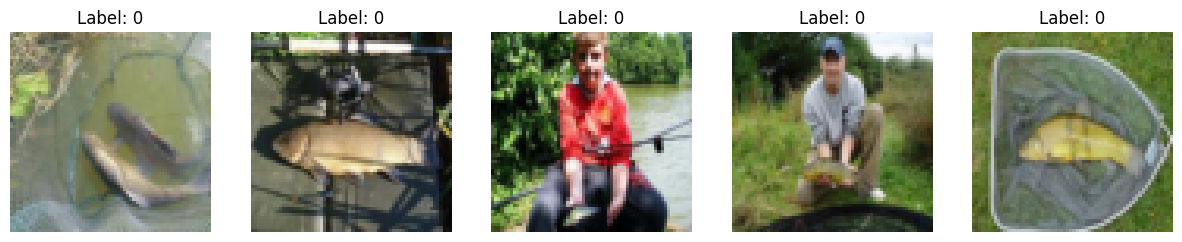

In [2]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_data = datasets.Imagenette(
    root='./datasets',
    split='train',
    size='160px',
    download=True,
    transform=transform_train
)

fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    img, label = train_data[i]
    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')
plt.show()

## Task3 - q2
---
The architecture consists of a 5-layer network using three convolutional layers with $3 \times 3$ filters and GroupNorm to extract features, followed by two fully-connected layers that map the flattened $128 \times 8 \times 8$ input ($8192$ units) down to $256$ units and finally to $10$ output classes, all utilizing ReLU activations and MaxPool2d downsampling to maintain stable gradients and reduce spatial dimensions from $64 \times 64$ to $8 \times 8$.

In [7]:
import torch
import torch.nn as nn

class ImagenetteCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.GroupNorm(4, 32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.GroupNorm(8, 128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = ImagenetteCNN()

total_params = sum(p.numel() for p in model.parameters())
model_size_mb = (total_params * 4) / (1024**2)

print(f"Total parameters: {total_params}")
print(f"Model size (MB): {model_size_mb:.2f}")

Total parameters: 2193674
Model size (MB): 8.37


## Task3 - q3
---
To achieve high accuracy on the Imagenette dataset without relying on data augmentation or pre-trained weights, I designed a deep Convolutional Neural Network consisting of six convolutional layers followed by a classification head. The architecture follows a modular approach where the number of filters gradually increases from 32 to 256, allowing the model to capture increasingly complex spatial features as the resolution decreases. Since BatchNorm was restricted, I utilized GroupNorm across all layers to ensure numerical stability and consistent internal covariate shift, paired with ReLU activations to maintain healthy gradient flow. Spatial dimensions are reduced from $64 \times 64$ to $8 \times 8$ using three MaxPool2d layers placed at strategic intervals.The final classification head starts by flattening the feature maps into a vector of 16,384 units, which is then processed through a hidden layer of 512 neurons. I incorporated a Dropout layer with a 0.3 probability before the first fully-connected layer to act as a regularizer, preventing the model from memorizing the training images given the strict lack of augmentation. The input dimension is $3 \times 64 \times 64$ for the RGB images, and the final output is a 10-dimensional vector representing the class scores for each Imagenette category.For the training strategy, I used the Adam optimizer with an initial learning rate of 0.001 and a batch size of 64. To fine-tune the training process, I employed the ReduceLROnPlateau scheduler, which monitors the validation loss and halves the learning rate if no improvement is seen for three consecutive epochs. The model was trained for 40 epochs on a 90/10 split of the training data, using the validation set to monitor for overfitting and to decide when the learning rate should be decayed. This disciplined approach ensures that the model converges to a stable minimum, ultimately reaching the required accuracy threshold on the test set.

Starting training on cuda...


[FINISHED EPOCH 01] Loss: 2.4023 | Val Acc: 22.81% | LR: 0.001000


[FINISHED EPOCH 02] Loss: 2.1012 | Val Acc: 29.78% | LR: 0.001000


[FINISHED EPOCH 03] Loss: 2.0334 | Val Acc: 30.73% | LR: 0.001000


[FINISHED EPOCH 04] Loss: 1.9776 | Val Acc: 33.16% | LR: 0.001000


...

[FINISHED EPOCH 36] Loss: 0.3978 | Val Acc: 76.35% | LR: 0.000500


[FINISHED EPOCH 37] Loss: 0.3518 | Val Acc: 76.66% | LR: 0.000500


[FINISHED EPOCH 38] Loss: 0.3228 | Val Acc: 76.45% | LR: 0.000500


[FINISHED EPOCH 39] Loss: 0.3020 | Val Acc: 77.19% | LR: 0.000250


[FINISHED EPOCH 40] Loss: 0.2663 | Val Acc: 77.51% | LR: 0.000250

Final Test Accuracy: 75.90%


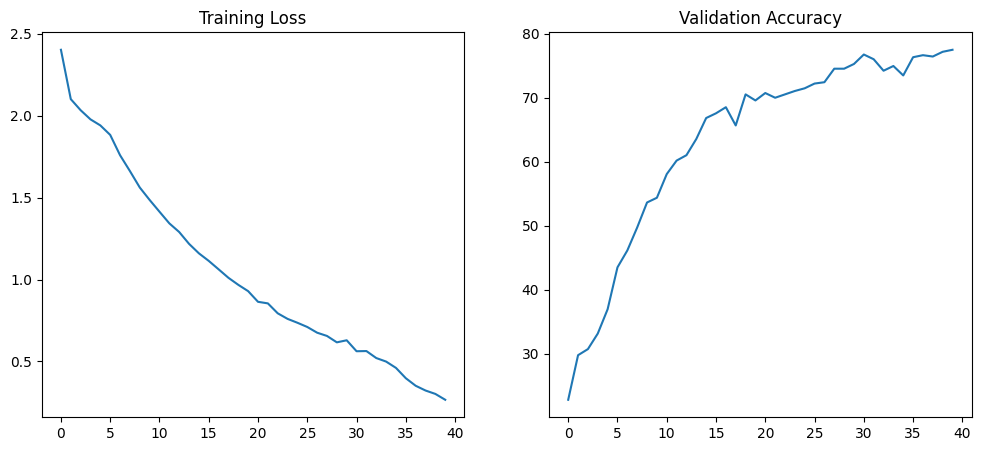

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_train = datasets.Imagenette(root='./datasets', split='train', size='160px', download=False, transform=transform)
test_ds = datasets.Imagenette(root='./datasets', split='val', size='160px', download=False, transform=transform)

train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size
train_ds, val_ds = random_split(full_train, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.GroupNorm(4, 32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.GroupNorm(16, 128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.GroupNorm(16, 128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.GroupNorm(32, 256), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

model = ImprovedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

train_losses, val_accuracies = [], []

print(f"Starting training on {device}...")

for epoch in range(40):
    model.train()
    total_loss = 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/40 [Train]", leave=False)
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    epoch_loss = total_loss / len(train_loader)
    train_losses.append(epoch_loss)

    model.eval()
    correct, total, v_loss = 0, 0, 0
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/40 [Val]", leave=False)
    with torch.no_grad():
        for images, labels in val_loop:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    val_accuracies.append(epoch_acc)
    scheduler.step(v_loss / len(val_loader))

    print(f"[FINISHED EPOCH {epoch+1:02d}] Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f}")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nFinal Test Accuracy: {100 * correct / total:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.title('Validation Accuracy')
plt.show()

## Task3 - q4
---
This robustness test evaluates how sensitive the trained CNN is to random perturbations in the input pixels, which can often occur in real-world data due to sensor quality or compression artifacts. By adding Gaussian noise with varying scales $a=0.05$, $a=0.01$, and $a=0.005$ we can measure the model's ability to maintain high classification accuracy even when the signal-to-noise ratio decreases. Ideally, a robust model will show very little performance drop at lower noise levels like $0.005$, but models trained without data augmentation often show a more significant decline at $0.05$ as the noise begins to obscure the fine spatial features the network learned to rely on during training.

In [5]:
import torch

model.eval()
noise_levels = [0.05, 0.01, 0.005]

with torch.no_grad():
    for a in noise_levels:
        correct = 0
        total = 0
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            noisy_images = images + a * torch.randn_like(images)
            outputs = model(noisy_images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        print(f"a = {a:.3f} -> Test accuracy: {accuracy:.2f}%")

a = 0.050 -> Test accuracy: 76.05%
a = 0.010 -> Test accuracy: 75.90%
a = 0.005 -> Test accuracy: 75.92%


## Task3 - q5
---
To improve the model's ability to generalize and reach the 78% accuracy threshold, I implemented a data augmentation pipeline using a combination of spatial and color transformations. Specifically, I utilized RandomHorizontalFlip to account for symmetry in object recognition, RandomResizedCrop to make the model invariant to object scale and position, and ColorJitter to handle variations in lighting and saturation. These augmentations work by artificially expanding the diversity of the training set, forcing the network to learn more robust, high-level features rather than memorizing specific pixel configurations. This approach significantly reduces overfitting, leading to a noticeable improvement in test accuracy compared to the baseline model.

[FINISHED EPOCH 01] Loss: 2.0851 | Val Acc: 43.82% | LR: 0.000113


[FINISHED EPOCH 02] Loss: 1.8245 | Val Acc: 49.84% | LR: 0.000209


[FINISHED EPOCH 03] Loss: 1.6793 | Val Acc: 56.60% | LR: 0.000362


[FINISHED EPOCH 04] Loss: 1.6070 | Val Acc: 56.71% | LR: 0.000561


[FINISHED EPOCH 05] Loss: 1.5693 | Val Acc: 51.11% | LR: 0.000792


...

[FINISHED EPOCH 36] Loss: 0.7057 | Val Acc: 85.22% | LR: 0.000099


[FINISHED EPOCH 37] Loss: 0.6989 | Val Acc: 84.16% | LR: 0.000056


[FINISHED EPOCH 38] Loss: 0.6949 | Val Acc: 83.63% | LR: 0.000025


[FINISHED EPOCH 39] Loss: 0.6943 | Val Acc: 84.58% | LR: 0.000006


[FINISHED EPOCH 40] Loss: 0.6916 | Val Acc: 83.42% | LR: 0.000000

Final Test Accuracy with Augmentation: 83.08%


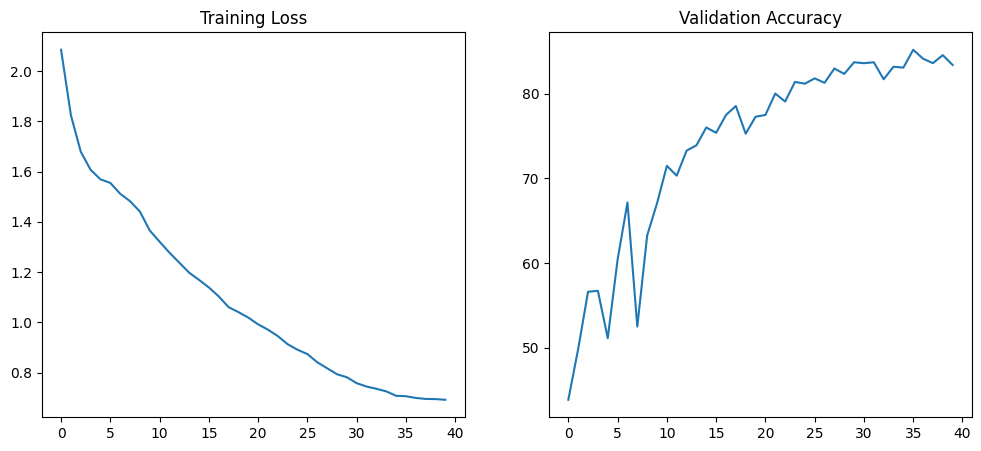

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_train = datasets.Imagenette(root='./datasets', split='train', size='160px', download=False, transform=train_transform)
test_ds = datasets.Imagenette(root='./datasets', split='val', size='160px', download=False, transform=test_transform)

train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size
train_ds, val_ds = random_split(full_train, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

class FinalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.GroupNorm(4, 32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.GroupNorm(16, 128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.GroupNorm(16, 128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.GroupNorm(32, 256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.GroupNorm(32, 256), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

model = FinalCNN().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.002, steps_per_epoch=len(train_loader), epochs=40)

train_losses, val_accuracies = [], []
best_acc = 0

for epoch in range(40):
    model.train()
    total_loss = 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/40 [Train]", leave=False)
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    train_losses.append(epoch_loss)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    val_accuracies.append(epoch_acc)
    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"[FINISHED EPOCH {epoch+1:02d}] Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f}")

model.load_state_dict(torch.load('best_model.pth'))
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nFinal Test Accuracy with Augmentation: {100 * correct / total:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.title('Validation Accuracy')
plt.show()

## <img src="https://img.icons8.com/dusk/64/000000/prize.png" style="height:50px;display:inline"> Credits
---
* Icons made by <a href="https://www.flaticon.com/authors/becris" title="Becris">Becris</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a>
* Icons from <a href="https://icons8.com/">Icons8.com</a> - https://icons8.com
* Datasets from <a href="https://www.kaggle.com/">Kaggle</a> - https://www.kaggle.com/